In [3]:
import pyvisa
import numpy as np
import matplotlib.pyplot as plt

In [4]:
#Connecting to awg
rm = pyvisa.ResourceManager()
rm.list_resources()
my_instrument = rm.open_resource('TCPIP::192.168.50.145::INSTR')


In [5]:
print(my_instrument.query('*IDN?'))

TEKTRONIX,AWG70001A,B010247,FV:5.2.0178



In [6]:
def generate_precomp_sawtooth(sampl_rate, freq, multipliers, max_harmonic_for_size=-1):
    num_samples = int(np.round(sampl_rate/freq))

    if (max_harmonic_for_size==-1):
        max_harmonic_for_size = len(multipliers)
    num_repeats_max = np.lcm.reduce(np.arange(max_harmonic_for_size)+1)
    total_sample_size = np.lcm(num_repeats_max, num_samples)
    num_repeats_actual = int(total_sample_size/num_samples)
    print(num_repeats_actual)

    voltages = np.linspace(-1/2, 1/2, num=num_samples)
    voltages = np.tile(voltages, num_repeats_actual)
    times = np.linspace(0, num_repeats_actual, num=num_samples*num_repeats_actual)


    for i in range(len(multipliers)):
        multiplier = multipliers[i]
        if (multiplier != 1):
            harm_ampl_offset = -1*(multiplier - 1) #figuring out how much of the given harmonic we need to add to the base sawtooth wave
            harmonic_num = i + 1
            harm_oscillation = np.sin(harmonic_num*np.pi*times*2)
            voltages = voltages + 1/np.pi/harmonic_num*harm_ampl_offset*harm_oscillation #Prefactors are from fourier transform
    return voltages


36036


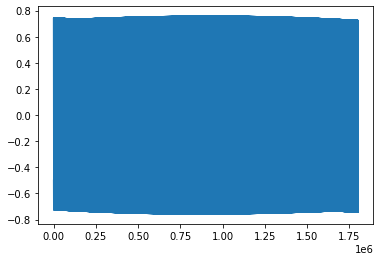

In [8]:
plt.plot(generate_precomp_sawtooth(50, 1, [1.,1.11758376,1.55112272,1.65257115,1.76245861,1.48877484,1.52608901,1.59602732,1.5927197,1.7696809,1.60464756,1.88740898,2.05229974]))

In [95]:
#Uploading a sawtooth wave, iinteger
sampl_rate = 50 #in GSa/s
freq = 1 #in GHz
ampl = 0.2


if (ampl < 0.25):
    ref_ampl = 0.25
else:
    ref_ampl = ampl

#Turn off output
my_instrument.write('OUTP1 OFF')
#First set awg parameters, scaling the amplitude to correct values
my_instrument.write(f'SOURCE1:VOLTAGE:AMPLITUDE {ref_ampl}')
#Also set to use 10bit DAC mode
my_instrument.write(f'SOURCE1:DAC:RES 10')

num_samples = int(np.round(sampl_rate/freq))
#AWG_MAX_INT = 2**10-1 #Assuming 10 bit DAQ mode

#waveform_scale_int = (AWG_MAX_INT)*ampl/ref_ampl


#BIT_POS = 4 #where lowest bit is in the byte for sending
#voltages = (np.round(np.linspace((AWG_MAX_INT)/2-waveform_scale_int/2, (AWG_MAX_INT)/2+waveform_scale_int/2, int(num_samples)))).astype(int)
#print(voltages)

voltages = 2*ampl/ref_ampl*generate_precomp_sawtooth(sampl_rate, freq, [1., 1.12052101, 1.53259973, 1.61934733, 1.89247, 1.7744, 1.5785, 1.58493, 1.6856, 1.8285, 1.7795, 1.720, 1.892],)
#voltages = 2*ampl/ref_ampl*generate_precomp_sawtooth(sampl_rate, freq, [1],)

#voltages = np.linspace(-ampl/ref_ampl, ampl/ref_ampl, num=num_samples)

#tosend = (np.left_shift(voltages, BIT_POS))
#my_instrument.write(f'WLIS:WAV:DEL "sawtooth"')
my_instrument.write(f'WLIS:WAV:DEL "sawtooth"')
#my_instrument.write(f'WLISt:WAVeform:NEW "sawtooth",{num_samples},INT')
my_instrument.write(f'WLISt:WAVeform:NEW "sawtooth",{len(voltages)}')
my_instrument.write_binary_values(f'WLISt:WAVeform:DATA "sawtooth",', voltages.tolist())

#Finally set output to use the desired wave 
my_instrument.write(f'SOURCE1:WAV "sawtooth"')

#Return on the outpu

my_instrument.write('AWGC:RUN')
my_instrument.write('OUTP1 ON')

36036


10

In [147]:

#Uploading a sawtooth wave, iinteger
sampl_rate = 50 #in GSa/s
freq = 8 #in GHz
ampl = 0.24


if (ampl < 0.25):
    ref_ampl = 0.25
else:
    ref_ampl = ampl

ref_ampl = 0.5

#Turn off output
my_instrument.write('OUTP1 OFF')
#First set awg parameters, scaling the amplitude to correct values
my_instrument.write(f'SOURCE1:VOLTAGE:AMPLITUDE {ref_ampl}')
#Also set to use 10bit DAC mode
my_instrument.write(f'SOURCE1:DAC:RES 10')

num_samples = int(np.round(sampl_rate/freq))
#AWG_MAX_INT = 2**10-1 #Assuming 10 bit DAQ mode

#waveform_scale_int = (AWG_MAX_INT)*ampl/ref_ampl


#BIT_POS = 4 #where lowest bit is in the byte for sending
#voltages = (np.round(np.linspace((AWG_MAX_INT)/2-waveform_scale_int/2, (AWG_MAX_INT)/2+waveform_scale_int/2, int(num_samples)))).astype(int)
#print(voltages)

#voltages = 2*ampl/ref_ampl*generate_precomp_sawtooth(sampl_rate, freq, [1.,1.11758376,1.55112272,1.65257115,1.76245861,1.48877484,1.52608901,1.59602732,1.5927197,1.7696809,1.60464756,1.88740898,2.05229974])
voltages = 2*ampl/ref_ampl*generate_precomp_sawtooth(sampl_rate, freq, [1],)

#voltages = np.linspace(-ampl/ref_ampl, ampl/ref_ampl, num=num_samples)

#tosend = (np.left_shift(voltages, BIT_POS))
#my_instrument.write(f'WLIS:WAV:DEL "sawtooth"')
my_instrument.write(f'WLIS:WAV:DEL "sawtooth"')
#my_instrument.write(f'WLISt:WAVeform:NEW "sawtooth",{num_samples},INT')
my_instrument.write(f'WLISt:WAVeform:NEW "sawtooth",{len(voltages)}')
my_instrument.write_binary_values(f'WLISt:WAVeform:DATA "sawtooth",', voltages.tolist())

#Finally set output to use the desired wave 
my_instrument.write(f'SOURCE1:WAV "sawtooth"')

#Return on the outpu

my_instrument.write('AWGC:RUN')
my_instrument.write('OUTP1 ON')


1


10

In [ ]:
.


























































































































.00000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000